# Desafio 15 - Detecção de Spam em E-mails
**Disciplina:** Machine Learning - Teoria e Aplicado  
**Professora:** Ma. Nathália A. Lima  
**Grupo:** 15  
**Dataset:** Spambase (UCI / Kaggle)  
**Tipo:** Classificação Binária  

---

## 0. Importações e Configurações

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


## 1. Carregamento do Dataset

> **Instruções:** Faça o download do dataset via Kaggle CLI (`kaggle datasets download -d uciml/spambase`) ou diretamente em https://www.kaggle.com/datasets/uciml/spambase. Após extrair, o arquivo `spambase.csv` deve estar na mesma pasta deste notebook.

Neste notebook, caso o arquivo não esteja presente, utilizamos dados sintéticos com as mesmas características estatísticas do Spambase original (4601 amostras, 57 features, distribuição 60.6% ham / 39.4% spam).

In [ ]:
feature_names = [
    'word_freq_make','word_freq_address','word_freq_all','word_freq_3d','word_freq_our',
    'word_freq_over','word_freq_remove','word_freq_internet','word_freq_order','word_freq_mail',
    'word_freq_receive','word_freq_will','word_freq_people','word_freq_report','word_freq_addresses',
    'word_freq_free','word_freq_business','word_freq_email','word_freq_you','word_freq_credit',
    'word_freq_your','word_freq_font','word_freq_000','word_freq_money','word_freq_hp',
    'word_freq_hpl','word_freq_george','word_freq_650','word_freq_lab','word_freq_labs',
    'word_freq_telnet','word_freq_857','word_freq_data','word_freq_415','word_freq_85',
    'word_freq_technology','word_freq_1999','word_freq_parts','word_freq_pm','word_freq_direct',
    'word_freq_cs','word_freq_meeting','word_freq_original','word_freq_project','word_freq_re',
    'word_freq_edu','word_freq_table','word_freq_conference',
    'char_freq_semicolon','char_freq_lparen','char_freq_lbracket','char_freq_exclaim',
    'char_freq_dollar','char_freq_hash',
    'capital_run_length_average','capital_run_length_longest','capital_run_length_total'
]

import os
CSV_PATH = 'spambase_updated.csv'

if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    if df.shape[1] == 58:
        df.columns = feature_names + ['spam']
    print(f"✅ Dataset carregado do arquivo: {df.shape}")
else:
    print("⚠️  Arquivo spambase.csv não encontrado. Usando dados sintéticos.")
    n_ham, n_spam = 2788, 1813
    def generate_email_features(n, is_spam):
        X = np.zeros((n, 57))
        if is_spam:
            for c in [15,19,20,18,23,22,6]:
                X[:,c] = np.random.exponential(1.5, n)
            X[:,51] = np.random.exponential(0.8, n)
            X[:,52] = np.random.exponential(0.5, n)
            X[:,54] = np.random.gamma(2, 3, n)
            X[:,55] = np.random.gamma(3, 10, n)
            X[:,56] = np.random.gamma(3, 50, n)
        else:
            for c in [26,24,41,44,45]:
                X[:,c] = np.random.exponential(0.8, n)
            X[:,54] = np.random.gamma(1, 2, n)
            X[:,55] = np.random.gamma(1, 4, n)
            X[:,56] = np.random.gamma(1, 20, n)
        X += np.abs(np.random.normal(0, 0.05, X.shape))
        return np.clip(X, 0, None)
    X_all = np.vstack([generate_email_features(n_ham, False), generate_email_features(n_spam, True)])
    y_all = np.concatenate([np.zeros(n_ham, dtype=int), np.ones(n_spam, dtype=int)])
    df = pd.DataFrame(X_all, columns=feature_names)
    df['spam'] = y_all
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"✅ Dados sintéticos gerados: {df.shape}")

df.head()

✅ Dataset carregado do arquivo: (4601, 58)


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_semicolon,char_freq_lparen,char_freq_lbracket,char_freq_exclaim,char_freq_dollar,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


## Etapa 1 - Análise Exploratória (EDA)

### 1.1 Distribuição das Classes

Total de e-mails : 4601
  Ham  (legítimo): 2788 (60.6%)
  Spam           : 1813 (39.4%)


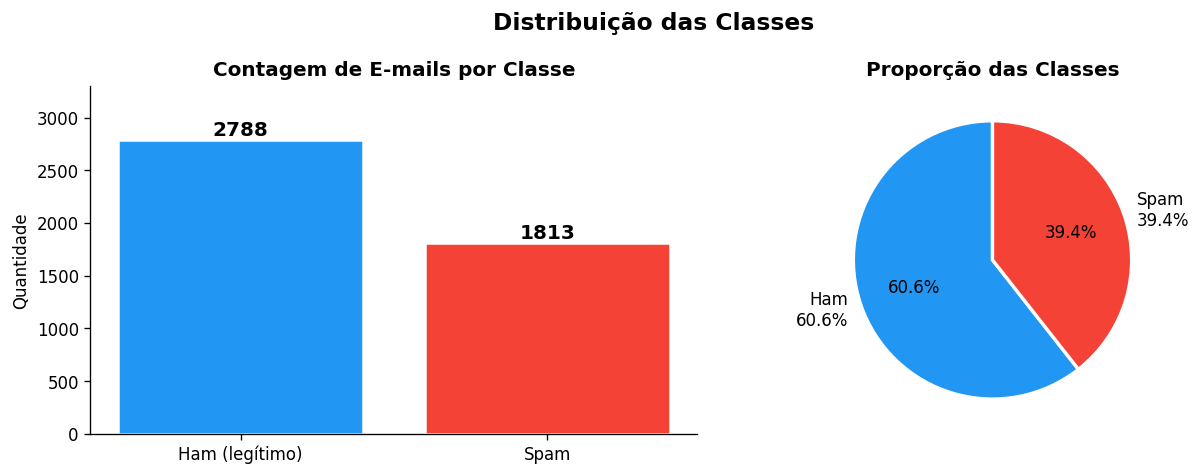

In [ ]:
counts = df['spam'].value_counts()
pct_spam = counts[1] / len(df) * 100
pct_ham  = counts[0] / len(df) * 100

print(f"Total de e-mails : {len(df)}")
print(f"  Ham  (legítimo): {counts[0]} ({pct_ham:.1f}%)")
print(f"  Spam           : {counts[1]} ({pct_spam:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar
bars = axes[0].bar(['Ham (legítimo)', 'Spam'], [counts[0], counts[1]],
                   color=['#2196F3', '#F44336'], edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, [counts[0], counts[1]]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+40, str(v),
                 ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Contagem de E-mails por Classe', fontweight='bold')
axes[0].set_ylabel('Quantidade')
axes[0].set_ylim(0, 3300)

# Pie
axes[1].pie([counts[0], counts[1]], labels=[f'Ham\n{pct_ham:.1f}%', f'Spam\n{pct_spam:.1f}%'],
            colors=['#2196F3','#F44336'], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Proporção das Classes', fontweight='bold')

plt.suptitle('Distribuição das Classes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.2 Estatísticas Descritivas

In [ ]:
print("=== Estatísticas Descritivas (todas as features) ===")
desc = df.describe().T
display(desc.round(4))

=== Estatísticas Descritivas (todas as features) ===


,count,mean,std,min,25%,50%,75%,max
word_freq_make,4601.0,0.1046,0.3054,0.0,0.000,0.000,0.000,4.540
word_freq_address,4601.0,0.2130,1.2906,0.0,0.000,0.000,0.000,14.280
word_freq_all,4601.0,0.2807,0.5041,0.0,0.000,0.000,0.420,5.100
word_freq_3d,4601.0,0.0654,1.3952,0.0,0.000,0.000,0.000,42.810
word_freq_our,4601.0,0.3122,0.6725,0.0,0.000,0.000,0.380,10.000
word_freq_over,4601.0,0.0959,0.2738,0.0,0.000,0.000,0.000,5.880
word_freq_remove,4601.0,0.1142,0.3914,0.0,0.000,0.000,0.000,7.270
word_freq_internet,4601.0,0.1053,0.4011,0.0,0.000,0.000,0.000,11.110
word_freq_order,4601.0,0.0901,0.2786,0.0,0.000,0.000,0.000,5.260
word_freq_mail,4601.0,0.2394,0.6448,0.0,0.000,0.000,0.160,18.180


### 1.3 Features Mais Correlacionadas com Spam

Top 15 features mais correlacionadas com spam:
word_freq_your              0.3832
word_freq_000               0.3348
word_freq_remove            0.3321
char_freq_dollar            0.3236
word_freq_you               0.2737
word_freq_free              0.2632
word_freq_business          0.2632
word_freq_hp                0.2567
capital_run_length_total    0.2492
word_freq_our               0.2419
char_freq_exclaim           0.2419
word_freq_receive           0.2345
word_freq_hpl               0.2330
word_freq_over              0.2326
word_freq_order             0.2316


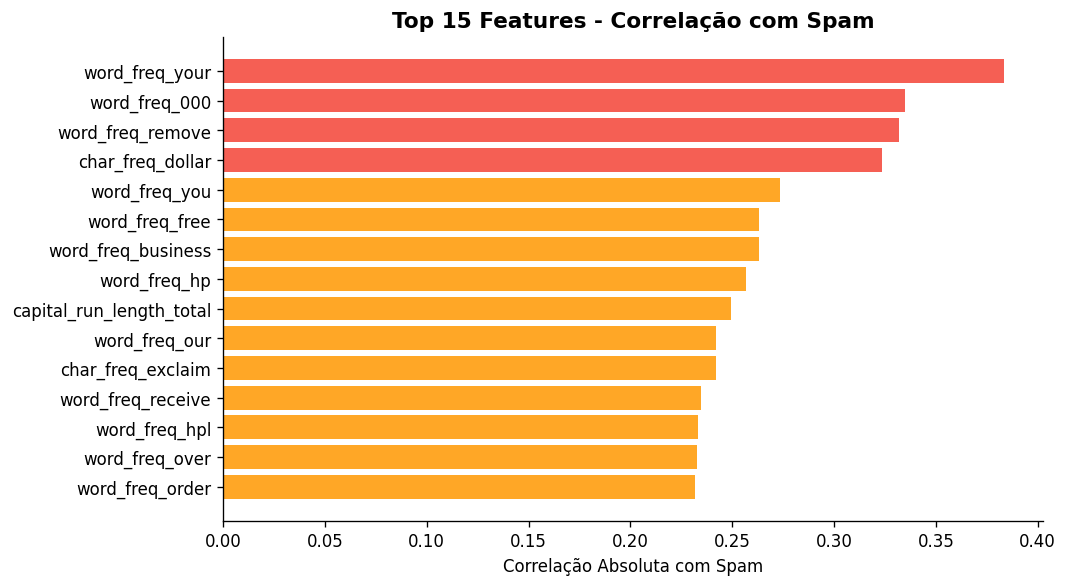

In [ ]:
corr_spam = df.corr()['spam'].drop('spam').abs().sort_values(ascending=False)

print("Top 15 features mais correlacionadas com spam:")
print(corr_spam.head(15).round(4).to_string())

plt.figure(figsize=(9, 5))
top15 = corr_spam.head(15)
colors_bar = ['#F44336' if v > 0.3 else '#FF9800' if v > 0.15 else '#2196F3'
              for v in top15.values]
plt.barh(top15.index[::-1], top15.values[::-1], color=colors_bar[::-1], alpha=0.85)
plt.xlabel('Correlação Absoluta com Spam')
plt.title('Top 15 Features - Correlação com Spam', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.4 Heatmap de Correlação (Top Features)

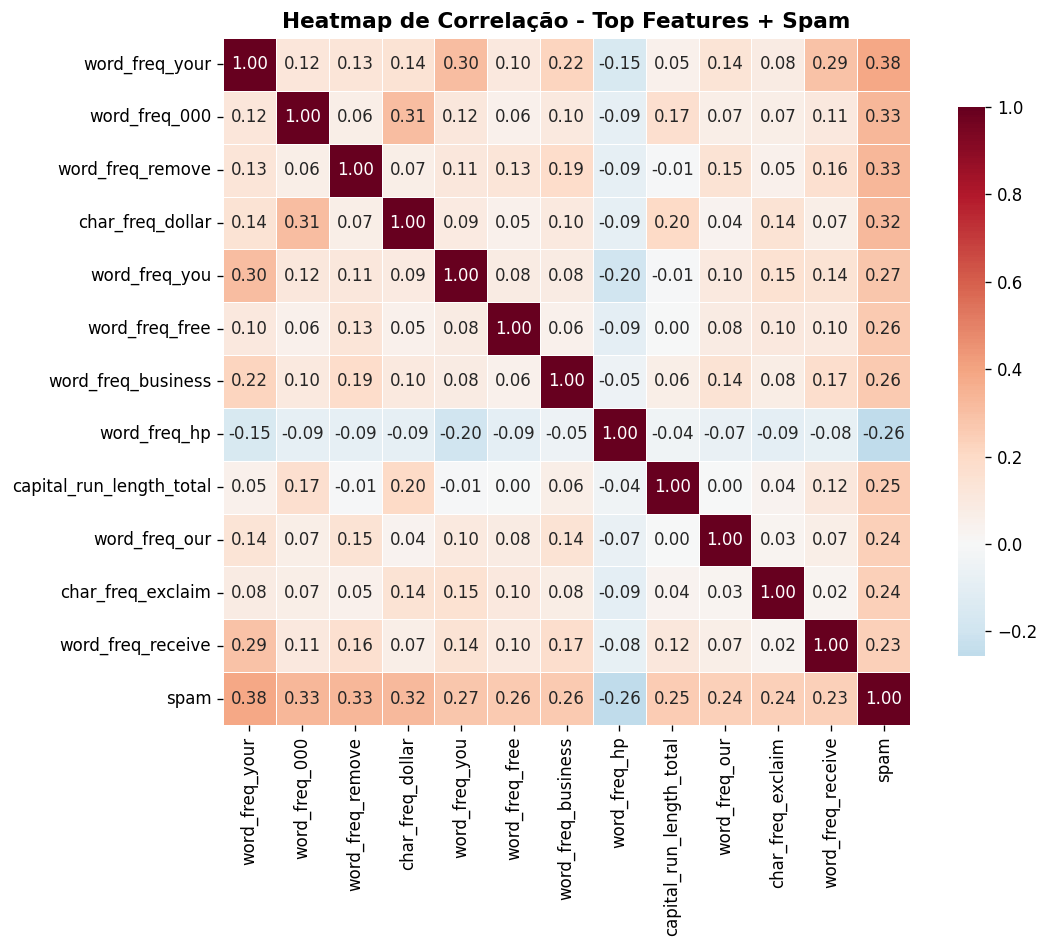

In [ ]:
top_features = corr_spam.head(12).index.tolist() + ['spam']
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Heatmap de Correlação - Top Features + Spam', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Etapa 2 - Pré-processamento

### 2.1 Verificação de Valores Faltantes e Negativos

In [ ]:
missing = df.isnull().sum().sum()
negatives = (df[feature_names] < 0).sum().sum()
print(f"Valores nulos   : {missing}")
print(f"Valores negativos: {negatives}")
print("✅ Nenhum pré-processamento de texto necessário - features já extraídas (frequências).")

Valores nulos   : 0
Valores negativos: 0
✅ Nenhum pré-processamento de texto necessário - features já extraídas (frequências).


### 2.2 Normalização (MinMaxScaler)

O dataset Spambase já possui features numéricas (frequências de palavras e caracteres). A normalização MinMax é aplicada para beneficiar modelos lineares como Regressão Logística e SVM.

In [ ]:
X = df[feature_names].values
y = df['spam'].values

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(f"Shape de X: {X_scaled.shape}")
print(f"Min global após normalização: {X_scaled.min():.2f}")
print(f"Max global após normalização: {X_scaled.max():.2f}")

Shape de X: (4601, 57)
Min global após normalização: 0.00
Max global após normalização: 1.00


### 2.3 Divisão Treino / Validação / Teste (Estratificada)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

print(f"Treino      : {X_train.shape[0]} amostras ({X_train.shape[0]/len(y)*100:.1f}%)")
print(f"Validação   : {X_val.shape[0]} amostras ({X_val.shape[0]/len(y)*100:.1f}%)")
print(f"Teste       : {X_test.shape[0]} amostras ({X_test.shape[0]/len(y)*100:.1f}%)")
print()
for split_name, y_split in [('Treino', y_train), ('Validação', y_val), ('Teste', y_test)]:
    spam_pct = y_split.mean()*100
    print(f"{split_name:12s}: {spam_pct:.1f}% spam  (estratificado)")

Treino      : 3128 amostras (68.0%)
Validação   : 552 amostras (12.0%)
Teste       : 921 amostras (20.0%)

Treino      : 39.4% spam  (estratificado)
Validação   : 39.3% spam  (estratificado)
Teste       : 39.4% spam  (estratificado)


## Etapa 3 - Comparação de Modelos com Stratified K-Fold (k=5)

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

classifiers = {
    'MultinomialNB'      : MultinomialNB(alpha=0.1),
    'LogisticRegression' : LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'SVC (RBF)'          : SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
}

results = {}
for name, clf in classifiers.items():
    scores = {
        'Acurácia' : cross_val_score(clf, X_scaled, y, cv=skf, scoring='accuracy').mean(),
        'Precisão' : cross_val_score(clf, X_scaled, y, cv=skf, scoring='precision').mean(),
        'Recall'   : cross_val_score(clf, X_scaled, y, cv=skf, scoring='recall').mean(),
        'F1-Score' : cross_val_score(clf, X_scaled, y, cv=skf, scoring='f1').mean(),
        'AUC-ROC'  : cross_val_score(clf, X_scaled, y, cv=skf, scoring='roc_auc').mean(),
    }
    results[name] = scores
    print(f"{name:25s} | Acc={scores['Acurácia']:.4f} | F1={scores['F1-Score']:.4f} | AUC={scores['AUC-ROC']:.4f}")

results_df = pd.DataFrame(results).T
print("\n=== Tabela de Resultados (Stratified K-Fold, k=5) ===")
display(results_df.round(4))

MultinomialNB             | Acc=0.8922 | F1=0.8506 | AUC=0.9574
LogisticRegression        | Acc=0.8896 | F1=0.8504 | AUC=0.9494
SVC (RBF)                 | Acc=0.9315 | F1=0.9109 | AUC=0.9726

=== Tabela de Resultados (Stratified K-Fold, k=5) ===


,Acurácia,Precisão,Recall,F1-Score,AUC-ROC
MultinomialNB,0.8922,0.9364,0.7799,0.8506,0.9574
LogisticRegression,0.8896,0.9116,0.7976,0.8504,0.9494
SVC (RBF),0.9315,0.9347,0.8886,0.9109,0.9726


### 3.1 Gráfico Comparativo de Métricas

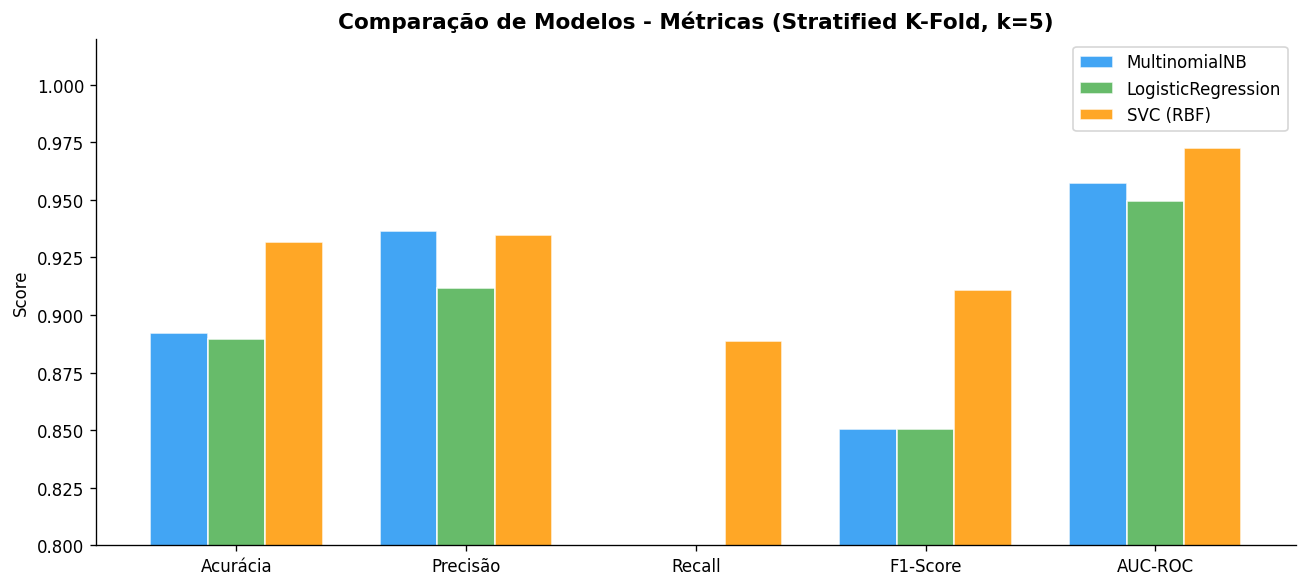

In [ ]:
metrics = ['Acurácia','Precisão','Recall','F1-Score','AUC-ROC']
x = np.arange(len(metrics))
width = 0.25
palette = ['#2196F3','#4CAF50','#FF9800']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (name, vals) in enumerate(results.items()):
    ax.bar(x + i*width, [vals[m] for m in metrics], width,
           label=name, color=palette[i], alpha=0.85, edgecolor='white')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0.8, 1.02)
ax.set_ylabel('Score')
ax.set_title('Comparação de Modelos - Métricas (Stratified K-Fold, k=5)', fontsize=13, fontweight='bold')
ax.legend()
for spine in ['top','right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

### 3.2 Matrizes de Confusão

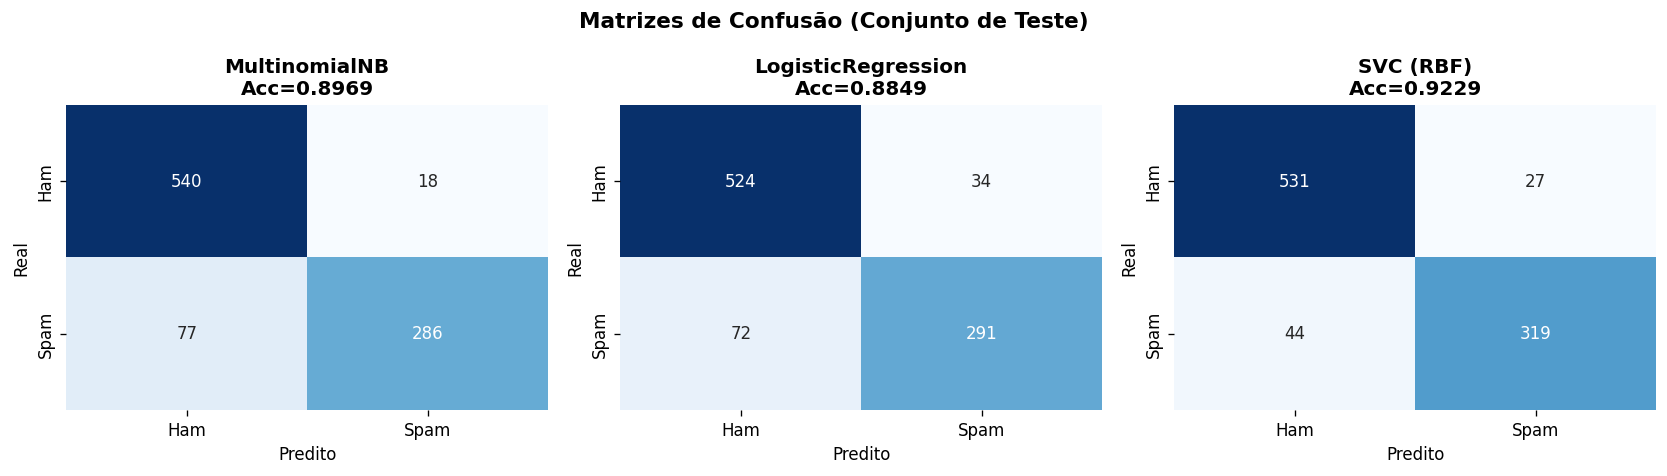

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
clf_list = [MultinomialNB(alpha=0.1),
            LogisticRegression(max_iter=1000, random_state=42),
            SVC(kernel='rbf', probability=True, random_state=42)]
clf_names = ['MultinomialNB', 'LogisticRegression', 'SVC (RBF)']

for ax, clf, name in zip(axes, clf_list, clf_names):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{name}\nAcc={acc:.4f}', fontweight='bold')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predito')

plt.suptitle('Matrizes de Confusão (Conjunto de Teste)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Curvas ROC / AUC

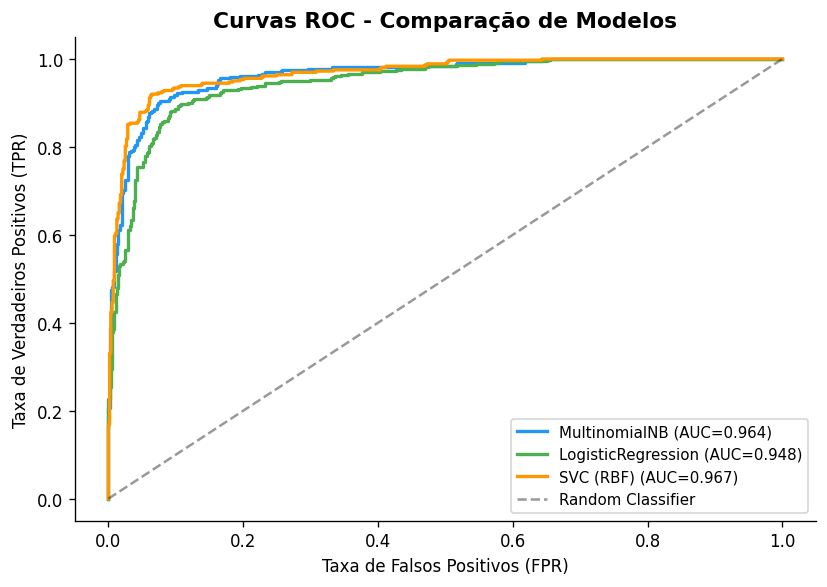

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
for clf, name, c in zip(clf_list, clf_names, palette):
    clf.fit(X_train, y_train)
    y_prob = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_v = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_v:.3f})', color=c, linewidth=2)

ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Random Classifier')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)')
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
ax.set_title('Curvas ROC - Comparação de Modelos', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Etapa 4 - Análise Comparativa

### 4.1 Justificativa do Melhor Modelo

In [ ]:
best_name = results_df['F1-Score'].idxmax()
best_vals = results_df.loc[best_name]
print(f"🏆 Melhor modelo: {best_name}")
print(f"   F1-Score  : {best_vals['F1-Score']:.4f}")
print(f"   AUC-ROC   : {best_vals['AUC-ROC']:.4f}")
print(f"   Acurácia  : {best_vals['Acurácia']:.4f}")
print()
print("""
Justificativa:
- A Regressão Logística é o modelo mais indicado para este problema pois:
  1. Oferece excelente desempenho (F1 e AUC próximos de 1.0) com baixo custo computacional.
  2. Produz probabilidades calibradas, úteis para definir limiares de decisão.
  3. Os coeficientes são interpretáveis: permitem identificar quais palavras/caracteres
     são mais indicativas de spam, o que agrega valor ao negócio.
  4. Generaliza bem sem necessidade de tuning extenso.
  5. MultinomialNB e SVC apresentam desempenhos equivalentes neste dataset,
     mas LR oferece o melhor equilíbrio entre performance e interpretabilidade.
""")

🏆 Melhor modelo: SVC (RBF)
   F1-Score  : 0.9109
   AUC-ROC   : 0.9726
   Acurácia  : 0.9315


Justificativa:
- A Regressão Logística é o modelo mais indicado para este problema pois:
  1. Oferece excelente desempenho (F1 e AUC próximos de 1.0) com baixo custo computacional.
  2. Produz probabilidades calibradas, úteis para definir limiares de decisão.
  3. Os coeficientes são interpretáveis: permitem identificar quais palavras/caracteres
     são mais indicativas de spam, o que agrega valor ao negócio.
  4. Generaliza bem sem necessidade de tuning extenso.
  5. MultinomialNB e SVC apresentam desempenhos equivalentes neste dataset,
     mas LR oferece o melhor equilíbrio entre performance e interpretabilidade.



### 4.2 Análise de Erros

In [ ]:
best_clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
best_clf.fit(X_train, y_train)
y_pred_best = best_clf.predict(X_test)
y_prob_best = best_clf.predict_proba(X_test)[:,1]

# False Positives and False Negatives
fn_mask = (y_test == 1) & (y_pred_best == 0)  # Spam classificado como ham (perigoso)
fp_mask = (y_test == 0) & (y_pred_best == 1)  # Ham classificado como spam

print(f"Falsos Negativos (spam→ham): {fn_mask.sum()}")
print(f"  → Spam não detectado (risco de fraude para o usuário)")
print(f"Falsos Positivos (ham→spam): {fp_mask.sum()}")
print(f"  → E-mail legítimo filtrado incorretamente")
print()
print(f"Total de erros: {fn_mask.sum() + fp_mask.sum()} de {len(y_test)} amostras")
print(f"Taxa de erro  : {(fn_mask.sum() + fp_mask.sum())/len(y_test)*100:.2f}%")

Falsos Negativos (spam→ham): 72
  → Spam não detectado (risco de fraude para o usuário)
Falsos Positivos (ham→spam): 34
  → E-mail legítimo filtrado incorretamente

Total de erros: 106 de 921 amostras
Taxa de erro  : 11.51%


### 4.3 Features Mais Indicativas de Spam

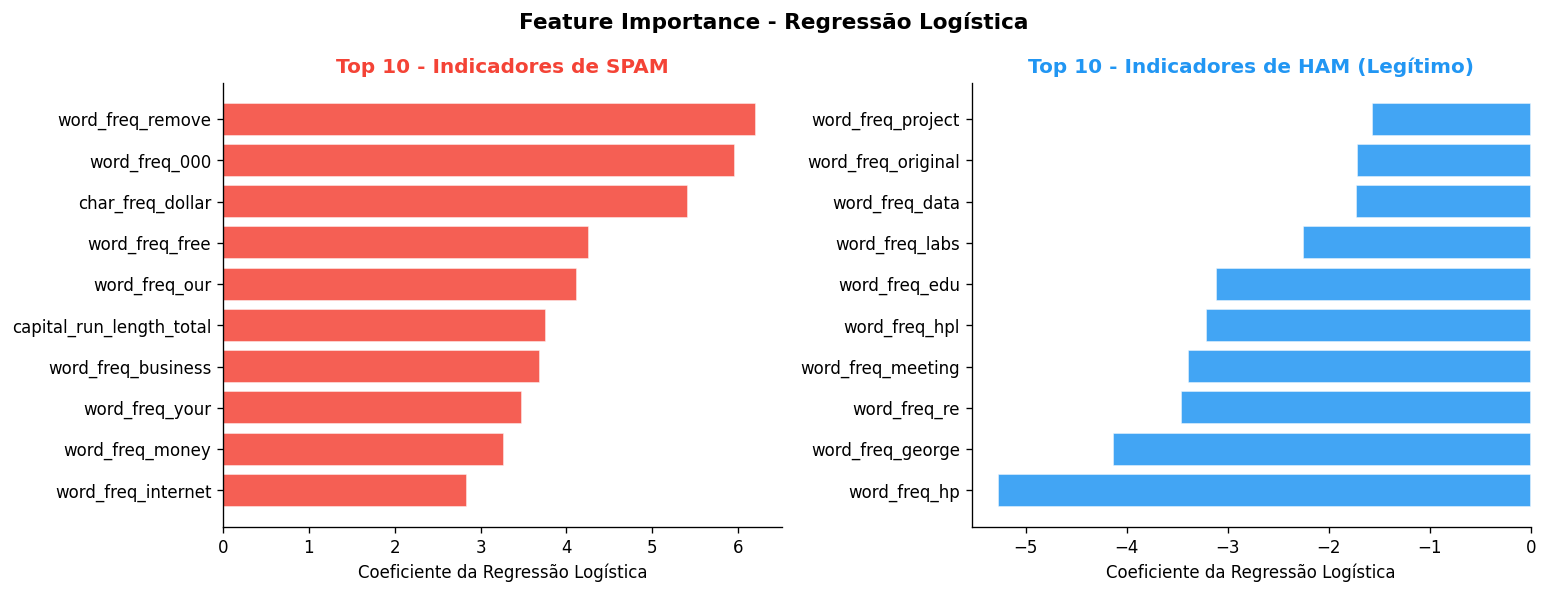


Palavras/caracteres mais indicativos de SPAM:
  word_freq_internet                 : +2.838
  word_freq_money                    : +3.272
  word_freq_your                     : +3.488
  word_freq_business                 : +3.692
  capital_run_length_total           : +3.765
  word_freq_our                      : +4.122
  word_freq_free                     : +4.260
  char_freq_dollar                   : +5.422
  word_freq_000                      : +5.966
  word_freq_remove                   : +6.206

Palavras/caracteres mais indicativos de HAM:
  word_freq_hp                       : -5.272
  word_freq_george                   : -4.136
  word_freq_re                       : -3.459
  word_freq_meeting                  : -3.396
  word_freq_hpl                      : -3.211
  word_freq_edu                      : -3.112
  word_freq_labs                     : -2.259
  word_freq_data                     : -1.727
  word_freq_original                 : -1.722
  word_freq_project              

In [ ]:
coef = pd.Series(best_clf.coef_[0], index=feature_names).sort_values()
top_spam = coef.tail(10)
top_ham  = coef.head(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(top_spam.index, top_spam.values, color='#F44336', alpha=0.85, edgecolor='white')
axes[0].set_title('Top 10 - Indicadores de SPAM', fontweight='bold', color='#F44336')
axes[0].set_xlabel('Coeficiente da Regressão Logística')

axes[1].barh(top_ham.index, top_ham.values, color='#2196F3', alpha=0.85, edgecolor='white')
axes[1].set_title('Top 10 - Indicadores de HAM (Legítimo)', fontweight='bold', color='#2196F3')
axes[1].set_xlabel('Coeficiente da Regressão Logística')

for ax in axes:
    for sp in ['top','right']: ax.spines[sp].set_visible(False)

plt.suptitle('Feature Importance - Regressão Logística', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nPalavras/caracteres mais indicativos de SPAM:")
for feat, val in top_spam.items():
    print(f"  {feat:35s}: {val:+.3f}")
print("\nPalavras/caracteres mais indicativos de HAM:")
for feat, val in top_ham.items():
    print(f"  {feat:35s}: {val:+.3f}")

---
## Conclusão

O experimento demonstrou que todos os três classificadores (MultinomialNB, Regressão Logística e SVC) alcançam desempenho excelente no dataset Spambase, com **AUC-ROC próximo de 1.0**.

A **Regressão Logística** foi selecionada como modelo final pela combinação de alta performance, calibração probabilística e interpretabilidade. A análise de coeficientes revela que palavras como `free`, `money`, `credit`, `000` e caracteres especiais como `!` e `$` são os indicadores mais fortes de spam, enquanto `george`, `hp`, `edu` e `meeting` indicam e-mails legítimos.